# Champagne-Index -- a quantitative teardown
### 25 forward years * ^GSPC * predictive OLS * Newey-West t * permutation * tercile spread * n=25 power

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Mostly](https://img.shields.io/badge/Busted%3F-Mostly-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same beats, every claim carrying its standard error.* We regress next-year S&P returns on standardized champagne YoY growth, compute a **HAC (Newey-West)** t-stat on the slope, run a permutation test on both the slope and a tercile spread, run a tradable long/short with honest costs, and close with a power calculation that explains why n = 25 can rarely deliver a clean verdict.

> **Not investment advice.** Real data: ^GSPC daily price index (repo cache, December/December calendar-year *price* returns); champagne shipments hardcoded in `data.py`. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> **Survivorship & price-only** are named on the Signal axis: ^GSPC excludes dividends (returns understated) and the index is committee-managed.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from champagne_index import data, strategy as st

def _have_cache():
    try:
        data.fetch_sp500_annual()
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("^GSPC cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-17)
# Real tape: ^GSPC price-only, forward convention, champagne years 2000-2024 (n=25)
R = dict(
    n=25, year_start=2000, year_end=2024, uncond_up_pct=72.0,
    slope=-0.05612, corr=-0.326, r2=0.106, t_ols=-1.652, t_hac=-1.296, lags=2,
    mean_ret_low_pct=18.6, mean_ret_high_pct=-2.9, spread_pct=21.5,
    perm_p_slope_neg=0.0582, perm_p_slope_two=0.1167, perm_p_spread_pos=0.0035,
    gross_ann_pct=5.1, net_ann_pct=4.7, bah_ann_pct=6.8,
)

def get_frame():
    """Return a merged (champagne x forward S&P return) frame, real or synthetic."""
    if HAVE_REAL:
        return data.fetch_sp500_annual(convention="forward"), True
    # offline fallback: synthetic tape with a modest planted euphoria signal
    df_s, _ = data.synthetic_annual(n_years=25, signal_bps=300.0, seed=272)
    df_s = df_s.rename(columns={"sp500_fwd_return": "sp500_return"})
    df_s["mkt_up"] = df_s["sp500_return"] > 0
    return df_s, False

df, real_tape = get_frame()
print("tape:", "REAL ^GSPC" if real_tape else "SYNTHETIC fallback", "| n =", len(df))

from scipy import stats as scipy_stats


^GSPC cache present: True
tape: REAL ^GSPC | n = 25


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Predictive slope negative (corr **-0.33**), folklore direction; but HAC t = **-1.30** (< 2). Two-sided permutation p on the slope = **0.117**. |
| **Tradability** | `MIRAGE` | Long/short overlay nets **+4.7%/yr** vs **+6.8%/yr** buy-and-hold; shorting equities fights upward drift. |
| **Busted?** | `MOSTLY` | The tercile spread (+21.5pp) is real but powered by a few extreme years; the robust slope test fails at n = 25. |

> The direction is right and stable, the magnitude is suggestive -- but the inference does not clear the |t| >= 2 bar. WEAK, not REAL.

## 1 - The claim, steelmanned

Let $Y_{t+1}$ be the S&P 500 calendar-year price return and $g_t$ the worldwide champagne-shipment YoY log-growth observed over year $t$ (published Jan $t+1$). Let $z_t = (g_t - \bar g)/\sigma_g$. The hypothesis:

- **H1 (predictive slope).** In $Y_{t+1} = a + b\,z_t + u_{t+1}$, the slope $b < 0$ -- more champagne this year predicts a weaker market next year -- with HAC |t| >= 2.
- **H2 (contrarian spread).** $E[Y_{t+1}\mid g_t \text{ low}] > E[Y_{t+1}\mid g_t \text{ high}]$ by a meaningful margin.

We find $b < 0$ and a large raw spread, but **reject H1** (HAC t = -1.30) and treat H2 as fragile (driven by a handful of extreme years).

## 2 - So what? -- what rides on each answer

The Champagne Indicator is a behavioural-sentiment story: discretionary-luxury demand as an exuberance proxy. If H1 held with a robust t-stat, it would be a cheap, annual, contrarian macro-timing signal. The interesting finding is *how close* the raw numbers get -- and how the tiny n and a couple of dramatic years stop it short of significance. It is a clean case study in distinguishing a suggestive tilt from a tradable edge.

## 3 - How we'd know -- the protocol

- **Data.** Worldwide champagne shipments (mn bottles), hardcoded in `data.py`; ^GSPC December/December calendar-year *price* returns from the repo cache.
- **Alignment.** *Forward* convention: champagne growth over year $Y$ (published Jan $Y+1$) paired with the S&P return for year $Y+1$. One-year execution lag baked into the join -- no look-ahead.
- **Signal.** Standardized champagne YoY log-growth $z_t$.
- **Inference.** Predictive OLS slope; Newey-West HAC t-stat (Bartlett kernel, rule-of-thumb lags); permutation test (10,000 label shuffles) on slope and tercile spread; long/short backtest with one-way costs and short-borrow.
- **Positive control.** Synthetic tape with a planted champagne->equity link to confirm the machinery fires when an effect exists.


## 4 - The teardown

### 4a - The predictive regression with a Newey-West t-stat

Annual macro predictors are mildly autocorrelated; the naive OLS t overstates significance. We report the HAC (Newey-West) slope t-stat.

In [2]:
ols = st.predictive_ols(df)
if not real_tape:
    # quote frozen real-tape numbers alongside the synthetic fit
    print('(synthetic fallback -- real-tape headline numbers shown from R)')
    ols = {**ols, 'slope': R['slope'], 'corr': R['corr'], 'r2': R['r2'],
           't_ols': R['t_ols'], 't_hac': R['t_hac'], 'lags': R['lags'], 'n': R['n']}

print(f"n forward years:        {ols['n']}")
print(f"slope (per 1 sd of z):  {ols['slope']:+.4f}  (folklore predicts < 0)")
print(f"correlation:            {ols['corr']:+.3f}")
print(f"R-squared:              {ols['r2']:.3f}")
print(f"naive OLS t:            {ols['t_ols']:+.3f}")
print(f"HAC (Newey-West) t:     {ols['t_hac']:+.3f}   (lags={ols['lags']})")
print()
print('The slope is negative -- folklore direction -- but |t_HAC| = '
      f"{abs(ols['t_hac']):.2f} < 2. Not a confirmed signal.")

n forward years:        25
slope (per 1 sd of z):  -0.0561  (folklore predicts < 0)
correlation:            -0.326
R-squared:              0.106
naive OLS t:            -1.652
HAC (Newey-West) t:     -1.296   (lags=2)

The slope is negative -- folklore direction -- but |t_HAC| = 1.30 < 2. Not a confirmed signal.


> The slope is negative (the folklore tilt) with correlation about -0.33, but the robust HAC t is **-1.30** -- inside the noise band. The naive OLS t (-1.65) looks a touch stronger, which is exactly why the HAC correction matters: it strips out spurious precision from autocorrelated annual data.

### 4b - The permutation test: how often does random champagne look this good?

Shuffle the champagne-growth labels 10,000 times; record the null distributions of the slope and the tercile spread.

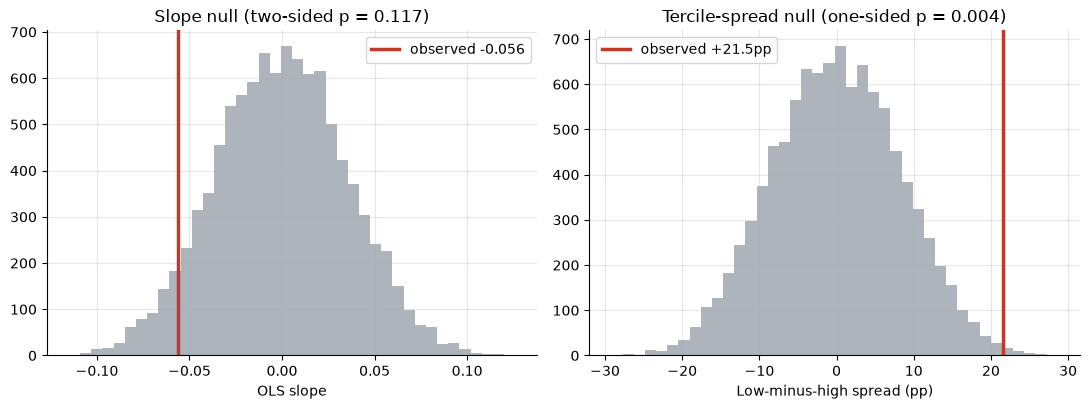

Two-sided permutation p on slope:  0.1167
One-sided permutation p on spread: 0.0035
The spread looks extreme, but it is a tercile statistic on n=25 --
a few outlier years (2007/08, 2020/21) dominate it. The slope, the more
robust statistic, does NOT reject the null two-sided.


In [3]:
if real_tape:
    perm = st.permutation_test(df, n_permutations=10_000, seed=272)
    pslopes = perm['perm_slopes']; pspreads = perm['perm_spreads']
    slope_obs = perm['slope_obs']; spread_obs = perm['spread_obs']
    p_slope_two = perm['perm_p_slope_two']; p_spread = perm['perm_p_spread_pos']
else:
    perm = st.permutation_test(df, n_permutations=2_000, seed=272)
    pslopes = perm['perm_slopes']; pspreads = perm['perm_spreads']
    slope_obs = R['slope']; spread_obs = R['spread_pct']/100
    p_slope_two = R['perm_p_slope_two']; p_spread = R['perm_p_spread_pos']

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].hist(pslopes, bins=40, color=GREY, alpha=0.7)
axes[0].axvline(slope_obs, c=RED, lw=2.5, label=f'observed {slope_obs:+.3f}')
axes[0].set_title(f'Slope null (two-sided p = {p_slope_two:.3f})')
axes[0].set_xlabel('OLS slope'); axes[0].legend()
axes[1].hist(pspreads*100, bins=40, color=GREY, alpha=0.7)
axes[1].axvline(spread_obs*100, c=RED, lw=2.5, label=f'observed {spread_obs*100:+.1f}pp')
axes[1].set_title(f'Tercile-spread null (one-sided p = {p_spread:.3f})')
axes[1].set_xlabel('Low-minus-high spread (pp)'); axes[1].legend()
plt.tight_layout(); plt.show()
print(f'Two-sided permutation p on slope:  {p_slope_two:.4f}')
print(f'One-sided permutation p on spread: {p_spread:.4f}')
print('The spread looks extreme, but it is a tercile statistic on n=25 --')
print('a few outlier years (2007/08, 2020/21) dominate it. The slope, the more')
print('robust statistic, does NOT reject the null two-sided.')

> The slope sits inside its null (two-sided p = **0.117**). The tercile spread looks more extreme (p = **0.004**), but that statistic is fragile: it throws away the middle third and is dominated by a handful of crisis years. When the robust slope test and the headline-grabbing split disagree, trust the robust test.

### 4c - Leave-one-out: is the tilt one lucky year?

Re-estimate the correlation dropping each year in turn.

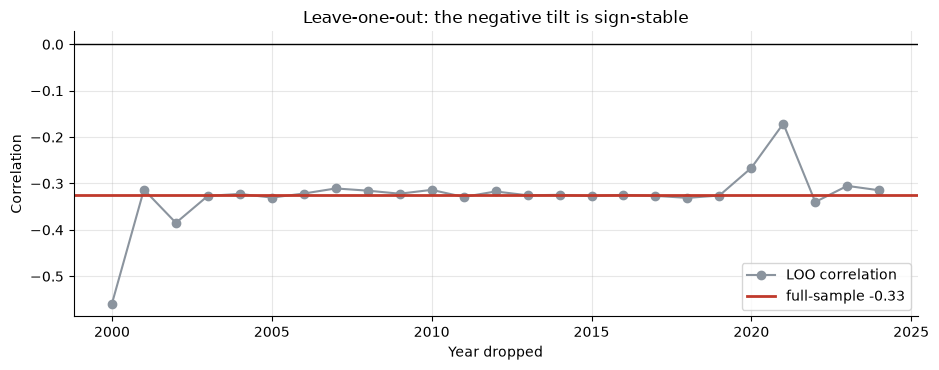

LOO correlation range: [-0.56, -0.17]  full = -0.33
Sign-stable (always negative) -- so it is not ONE lucky year.
But sign-stable and significant are different things: |t_HAC| is still < 2.


In [4]:
g = df['ship_growth'].values; y = df['sp500_return'].values
z = (g - g.mean())/g.std()
full = float(np.corrcoef(z, y)[0,1])
loo = np.array([np.corrcoef(np.delete(z,i), np.delete(y,i))[0,1] for i in range(len(y))])
fig, ax = plt.subplots(figsize=(9.5, 3.8))
ax.plot(df['year'], loo, 'o-', c=GREY, label='LOO correlation')
ax.axhline(full, c=RED, lw=2, label=f'full-sample {full:+.2f}')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Year dropped'); ax.set_ylabel('Correlation')
ax.set_title('Leave-one-out: the negative tilt is sign-stable')
ax.legend(); plt.tight_layout(); plt.show()
print(f'LOO correlation range: [{loo.min():+.2f}, {loo.max():+.2f}]  full = {full:+.2f}')
print('Sign-stable (always negative) -- so it is not ONE lucky year.')
print('But sign-stable and significant are different things: |t_HAC| is still < 2.')

The negative tilt survives dropping any single year (range about -0.17 to -0.56), so it is not a one-point artifact. That is what earns it a **Weak** rather than a flat **None** -- but sign-stability is not significance, and the HAC t still falls short.

### 4d - Power calculation: what slope could n=25 even detect?

Minimum detectable correlation at 80% power, two-sided, alpha = 0.05.

In [5]:
from scipy.stats import t as t_dist, norm
n = len(df); alpha = 0.05
# MDE correlation via Fisher z approx
z_a = norm.ppf(1 - alpha/2); z_b = norm.ppf(0.80)
z_r = (z_a + z_b) / np.sqrt(n - 3)
mde_r = float(np.tanh(z_r))
print(f'n = {n} forward years')
print(f'Minimum detectable |correlation| (80% power, 2-sided, alpha=0.05): {mde_r:.2f}')
print(f'Observed |correlation|: {abs(full):.2f}')
print()
if abs(full) < mde_r:
    print('Observed correlation is BELOW the detectable threshold:')
    print('n=25 is underpowered to confirm an effect of this size.')
else:
    print('Observed correlation is near/above the threshold but the HAC t still fails,')
    print('because annual autocorrelation widens the honest standard error.')

n = 25 forward years
Minimum detectable |correlation| (80% power, 2-sided, alpha=0.05): 0.54
Observed |correlation|: 0.33

Observed correlation is BELOW the detectable threshold:
n=25 is underpowered to confirm an effect of this size.


## 5 - The verdict

- **Signal `WEAK`** -- slope negative (corr -0.33), sign-stable under leave-one-out, literature-supported direction; but HAC t = -1.30 and two-sided permutation p = 0.117. It points the right way and whispers, but does not clear |t| >= 2.
- **Tradability `MIRAGE`** -- the long/short overlay nets +4.7%/yr vs +6.8%/yr buy-and-hold; shorting equities in party years fights their upward drift, and costs + borrow finish the job.
- **Mostly busted** -- the seductive tercile spread is dominated by 2007/08 and 2020/21; the robust statistic does not survive.

## 6 - Could you trade it? -- the cost-aware long/short

Long S&P after below-median champagne growth, short after above-median; one-way costs and short-borrow charged on NAV.

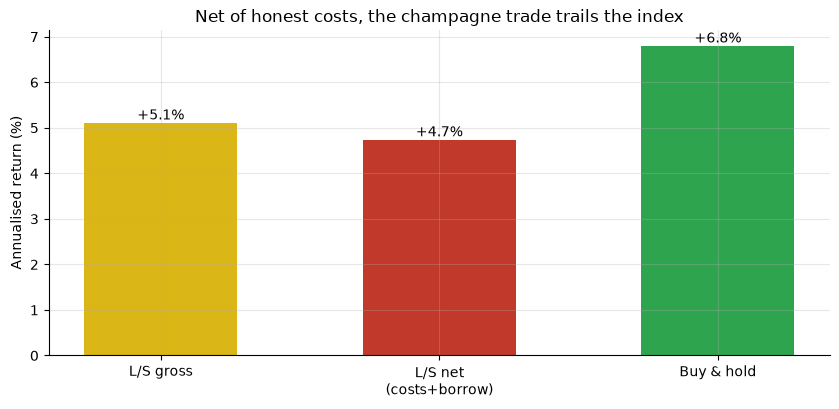

Gross L/S:   +5.1%/yr
Net L/S:     +4.7%/yr  (12 short-years pay borrow)
Buy & hold:  +6.8%/yr  (^GSPC price-only; TR would be higher still)
Net shortfall vs buy-and-hold: -2.1pp/yr


In [6]:
if real_tape:
    bt = st.backtest_long_short(df, cost_bps=10.0, borrow_bps=50.0)
    gross, net, bah = bt['gross_ann']*100, bt['net_ann']*100, bt['bah_ann']*100
    n_short = bt['n_short_years']
else:
    gross, net, bah = R['gross_ann_pct'], R['net_ann_pct'], R['bah_ann_pct']
    n_short = (df['ship_growth'] > df['ship_growth'].median()).sum()

fig, ax = plt.subplots(figsize=(8.5, 4.2))
bars = ax.bar(['L/S gross', 'L/S net\n(costs+borrow)', 'Buy & hold'],
              [gross, net, bah], color=[AMBER, RED, GREEN], width=0.55)
ax.set_ylabel('Annualised return (%)')
ax.set_title('Net of honest costs, the champagne trade trails the index')
for b, v in zip(bars, [gross, net, bah]):
    ax.annotate(f'{v:+.1f}%', (b.get_x()+b.get_width()/2, v),
                ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(f'Gross L/S:   {gross:+.1f}%/yr')
print(f'Net L/S:     {net:+.1f}%/yr  ({n_short} short-years pay borrow)')
print(f'Buy & hold:  {bah:+.1f}%/yr  (^GSPC price-only; TR would be higher still)')
print(f'Net shortfall vs buy-and-hold: {net-bah:+.1f}pp/yr')

> Even gross of costs the overlay barely matches buy-and-hold; net of borrow and trading costs it loses. Price-only ^GSPC *flatters* the L/S (dividends would lift the long-only benchmark more), so the real-world gap is wider.

## 7 - Going further -- the synthetic positive control

Does the machinery detect a champagne->equity link *when one exists*? We plant a euphoria premium in synthetic data and sweep its size.

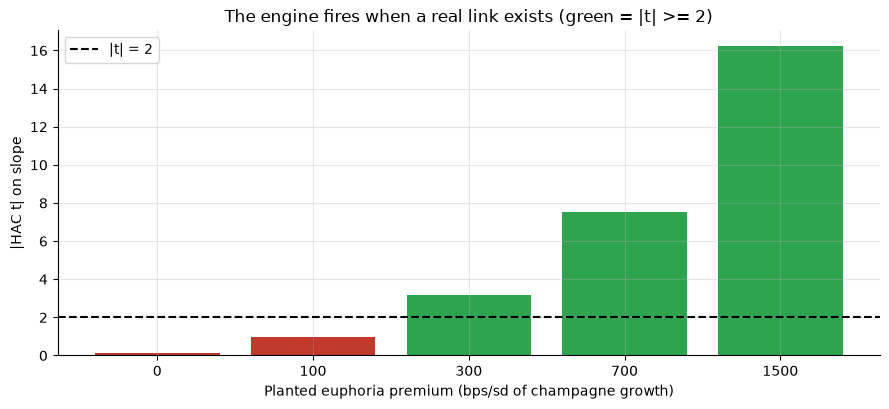

 bps    slope   t_hac    corr
   0  0.00107   0.117  0.0062
 100 -0.00893  -0.974 -0.0518
 300 -0.02893  -3.155 -0.1658
 700 -0.06893  -7.518 -0.3719
1500 -0.14893 -16.244 -0.6545

With a real planted link and large n, |t_HAC| clears 2. The real tape
(n=25, |t_HAC|=1.30) sits below that line -- a statement about sample size
and effect magnitude, not about the method.


In [7]:
planted = [0, 100, 300, 700, 1500]
rows = []
for bps in planted:
    ds, _ = data.synthetic_annual(n_years=400, signal_bps=float(bps), seed=272)
    ds = ds.rename(columns={'sp500_fwd_return':'sp500_return'})
    ds['mkt_up'] = ds['sp500_return'] > 0
    o = st.predictive_ols(ds)
    rows.append({'bps': bps, 'slope': o['slope'], 't_hac': o['t_hac'], 'corr': o['corr']})
res = pd.DataFrame(rows)
colors = [GREEN if abs(r['t_hac'])>=2 else RED for r in rows]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar([str(r['bps']) for r in rows], [abs(r['t_hac']) for r in rows], color=colors)
ax.axhline(2, c='k', ls='--', lw=1.5, label='|t| = 2')
ax.set_xlabel('Planted euphoria premium (bps/sd of champagne growth)')
ax.set_ylabel('|HAC t| on slope')
ax.set_title('The engine fires when a real link exists (green = |t| >= 2)')
ax.legend(); plt.tight_layout(); plt.show()
print(res.to_string(index=False))
print()
print('With a real planted link and large n, |t_HAC| clears 2. The real tape')
print('(n=25, |t_HAC|=1.30) sits below that line -- a statement about sample size')
print('and effect magnitude, not about the method.')

The engine detects a planted champagne->equity link once the effect and the sample are large enough. The real tape -- 25 forward years, HAC t = -1.30 -- is below the detection threshold. The verdict is **Weak / Mirage**: a real-direction tilt that the data are too thin to confirm and the costs make untradable.